In [1]:
from pathlib import Path

import pandas as pd

import jax
import jax.numpy as jnp
import jax.tree_util as jtu

from DiffFlowTransport.utils.plot import plot_timeseries_obs_1to1, plot_PQET_quantile
from DiffFlowTransport.utils.plot import plot_PQET_ST, plot_PQET_ST2, plot_young_water
from DiffFlowTransport.utils.plot import plot_timeseries, plot_J_Q
from DiffFlowTransport.model import load_model

import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2
# %reload_ext autoreload
    

In [2]:
# import os
# os.chdir('../')

# Load model

In [3]:
# model_name = 'mdn-couplingtype0'
model_name = 'mdn-couplingtype3'

f_configs = f'configs-{model_name}.json'


In [4]:
model, loss, flow_dl, transport_data, configs = load_model(f_configs)


INFO:2025-03-03 10:16:13,937:jax._src.xla_bridge:945: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2025-03-03 10:16:13,937 - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2025-03-03 10:16:13,946:jax._src.xla_bridge:945: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2025-03-03 10:16:13,946 - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


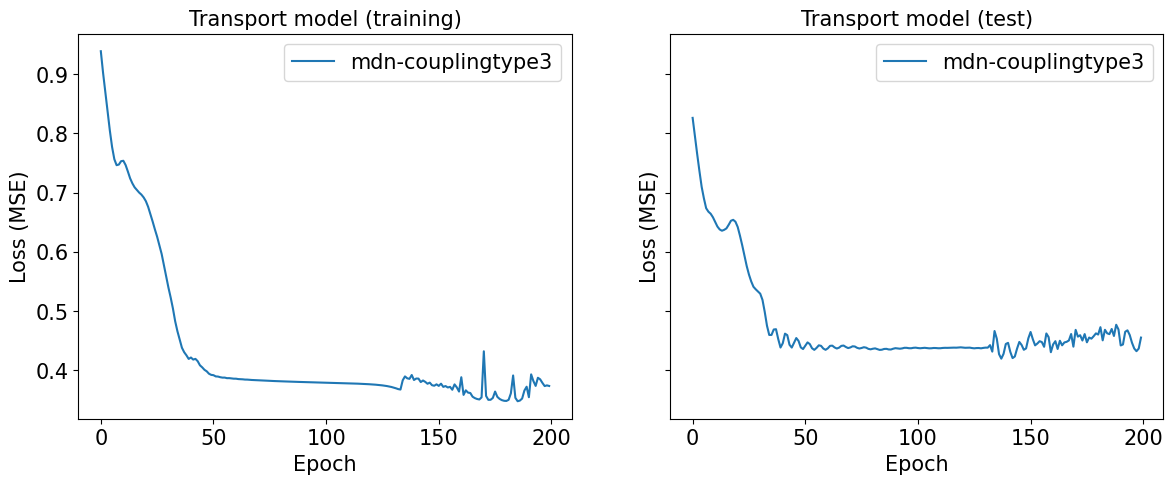

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)
axes[0].plot(loss['transport_loss']['train'], label=model_name)
axes[1].plot(loss['transport_loss']['test'], label=model_name)

for i,ax in enumerate(axes):
    ax.set(xlabel='Epoch', ylabel='Loss (MSE)', 
           title='Transport model (training)' if i==0 else 'Transport model (test)')
    ax.legend()


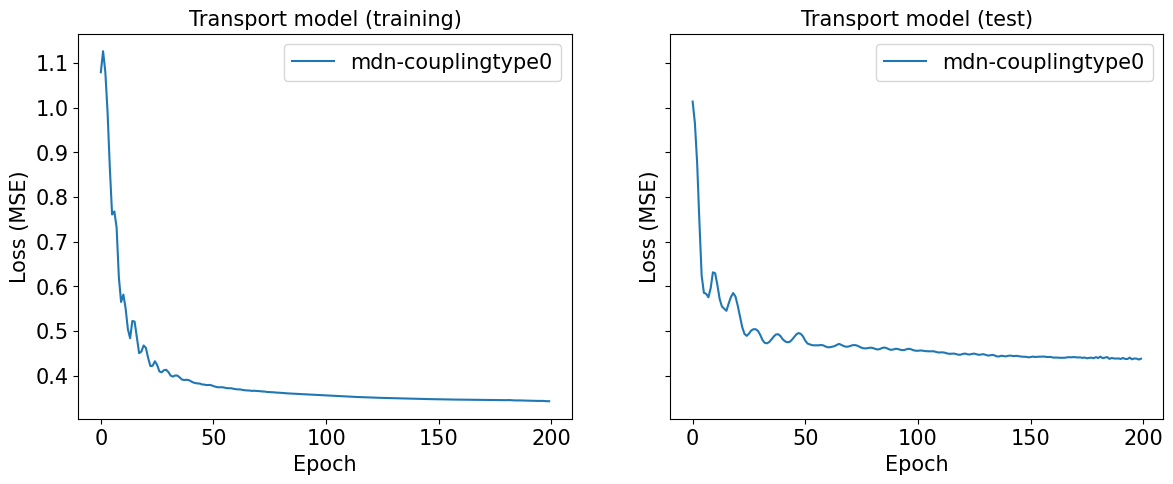

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)
axes[0].plot(loss['transport_loss']['train'], label=model_name)
axes[1].plot(loss['transport_loss']['test'], label=model_name)

for i,ax in enumerate(axes):
    ax.set(xlabel='Epoch', ylabel='Loss (MSE)', 
           title='Transport model (training)' if i==0 else 'Transport model (test)')
    ax.legend()


# Run the model

In [6]:
# Run the models
J, Q, ET, C_J, C_Q, time = transport_data
transport_output, _ = model.run_transport(J, C_J, ET, Q, dl=flow_dl)
transport_output_noQ, flow_output = model.run_transport(J, C_J, ET, Q=None, dl=flow_dl)


In [7]:
# Get the MDN weights
mdn_w = model.get_mdn_weights(Q=Q, dl=flow_dl)
mdn_w_noQ = model.get_mdn_weights(dl=flow_dl)

In [8]:
sT, mT, mQETs, pQETs, mRs, C_Q_pred = transport_output
C_Q_pred2 = transport_output_noQ[-1]
Q_pred = flow_output
data = list(zip(J, Q, Q_pred.flatten(), ET, C_J.flatten(), 
                C_Q.flatten(), C_Q_pred.flatten(), C_Q_pred2.flatten()))
df = pd.DataFrame(data, columns=['J', 'Q', 'Q_simb', 'ET', 'C_J', 'C_Q', 'C_Q_sim', 'C_Q_simb']).astype(float)
df.index = time


# Post-analysis

In [9]:
train_s, train_e = configs['train_configs']['train_start'], configs['train_configs']['train_end']
test_s, test_e = configs['train_configs']['test_start'], configs['train_configs']['test_end']
dt = configs['transport_configs']['transport_specs']['dt']


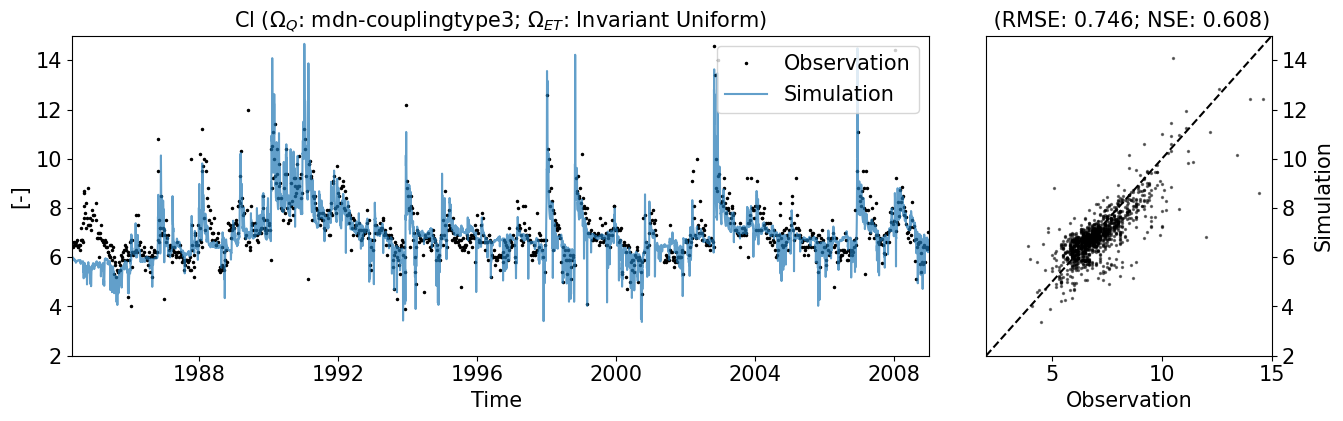

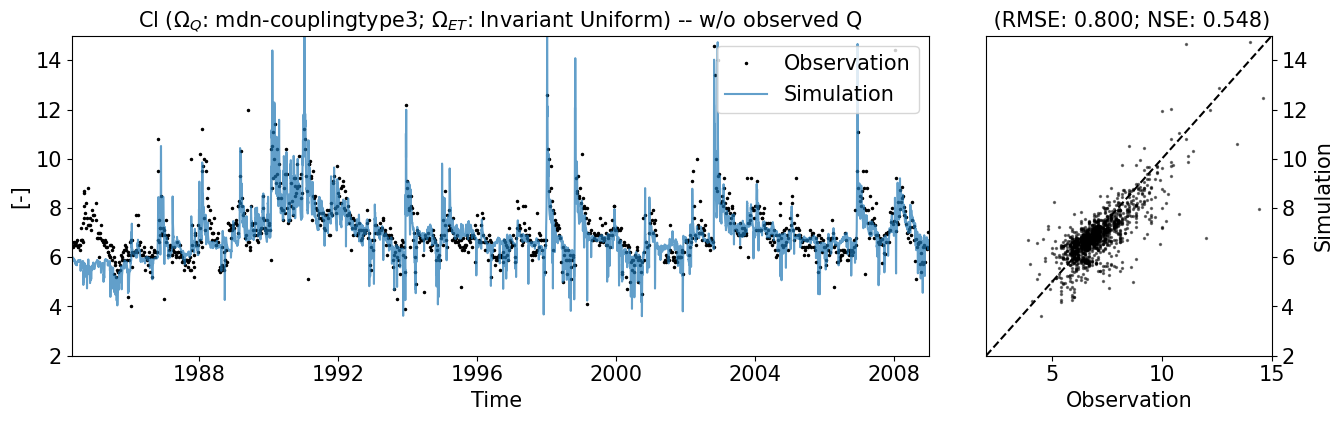

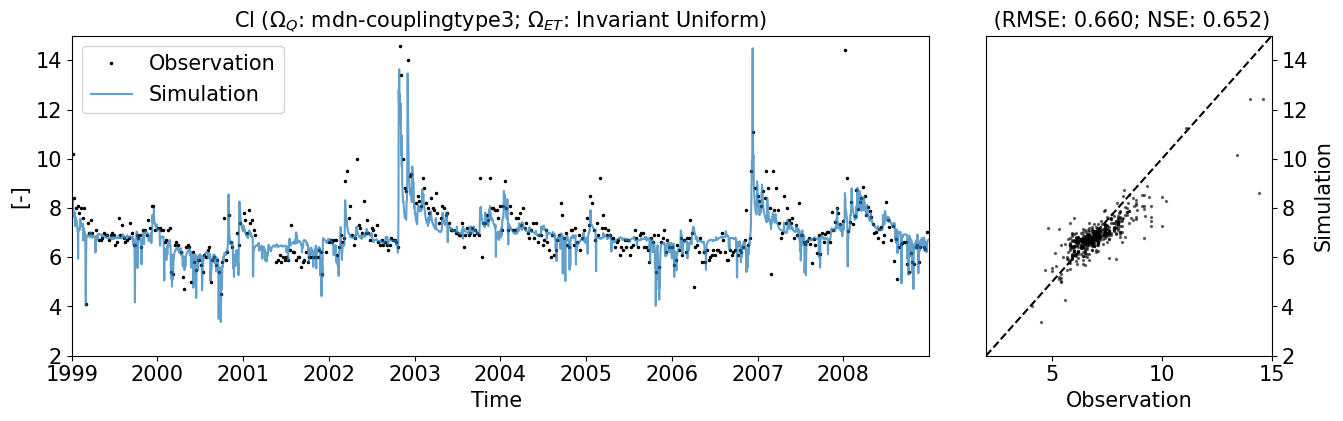

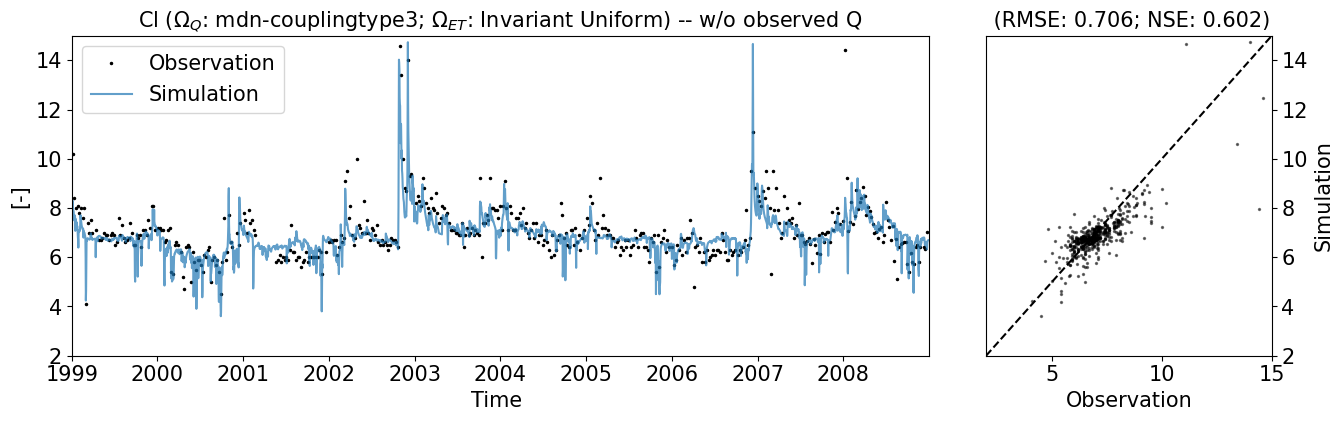

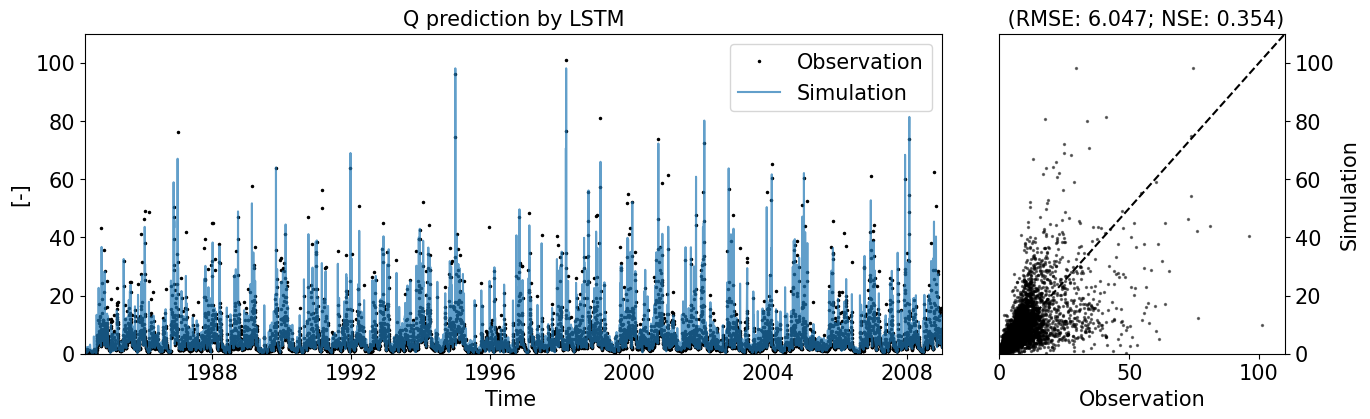

In [10]:
# Plot the C_J simulation
plot_timeseries_obs_1to1(
    obs=df['C_Q'].values, sim=df['C_Q_sim'].values, lim=[2,15], timesteps=df.index,
    varn=f'Cl ($\Omega_Q$: {model_name}; ' + '$\Omega_{ET}$: Invariant Uniform)'
);
plot_timeseries_obs_1to1(
    obs=df['C_Q'].values, sim=df['C_Q_simb'].values, lim=[2,15], timesteps=df.index,
    varn=f'Cl ($\Omega_Q$: {model_name}; ' + '$\Omega_{ET}$: Invariant Uniform) -- w/o observed Q'
);
# Plot the C_J simulation
plot_timeseries_obs_1to1(
    obs=df[test_s:test_e]['C_Q'].values, sim=df[test_s:test_e]['C_Q_sim'].values, lim=[2,15], timesteps=df[test_s:test_e].index,
    varn=f'Cl ($\Omega_Q$: {model_name}; ' + '$\Omega_{ET}$: Invariant Uniform)'
);
plot_timeseries_obs_1to1(
    obs=df[test_s:test_e]['C_Q'].values, sim=df[test_s:test_e]['C_Q_simb'].values, lim=[2,15], timesteps=df[test_s:test_e].index,
    varn=f'Cl ($\Omega_Q$: {model_name}; ' + '$\Omega_{ET}$: Invariant Uniform) -- w/o observed Q'
);
plot_timeseries_obs_1to1(
    obs=df['Q'].values, sim=df['Q_simb'].values, lim=[0,110], timesteps=df.index,
    varn='Q prediction by LSTM'
);


(Array([0.22953539, 0.0029702 , 0.7674945 ], dtype=float32),
 Array([0.22340325, 0.0029743 , 0.77362263], dtype=float32))

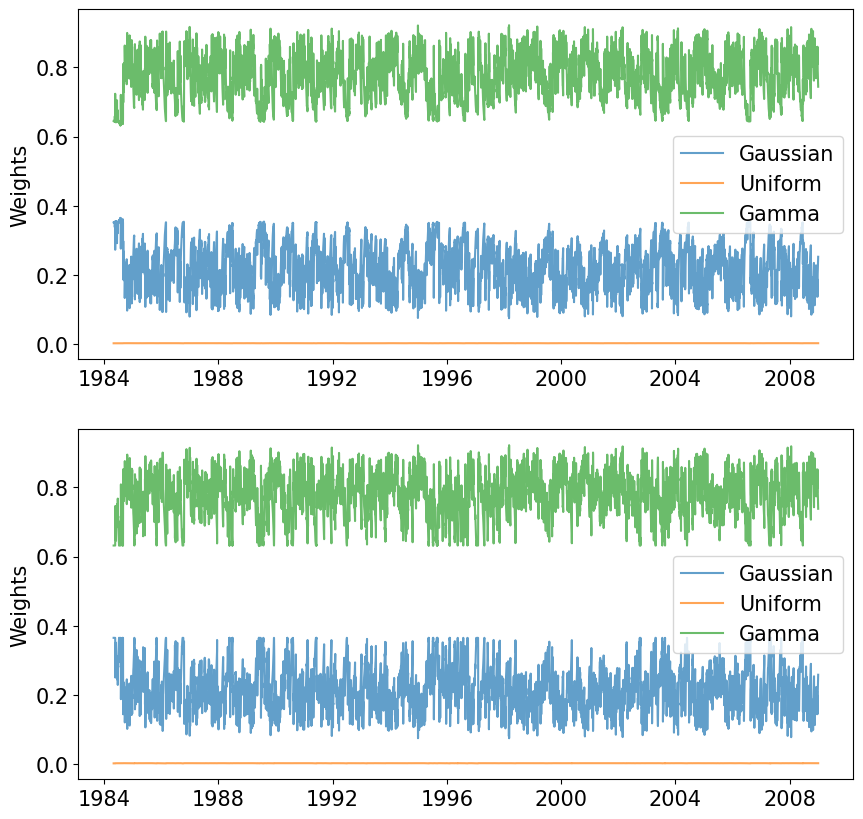

In [11]:
# MDN weights
distributions = ['Gaussian', 'Uniform', 'Gamma']
fig, axes = plt.subplots(2, 1, figsize=(10,10))
for i,dist in enumerate(distributions):
    axes[0].plot(time, mdn_w[:,i], alpha=0.7, label=dist)
    axes[1].plot(time, mdn_w_noQ[:,i], alpha=0.7, label=dist)
for ax in axes:
    ax.set(ylabel='Weights')
    ax.legend()
mdn_w.mean(axis=0), mdn_w_noQ.mean(axis=0)


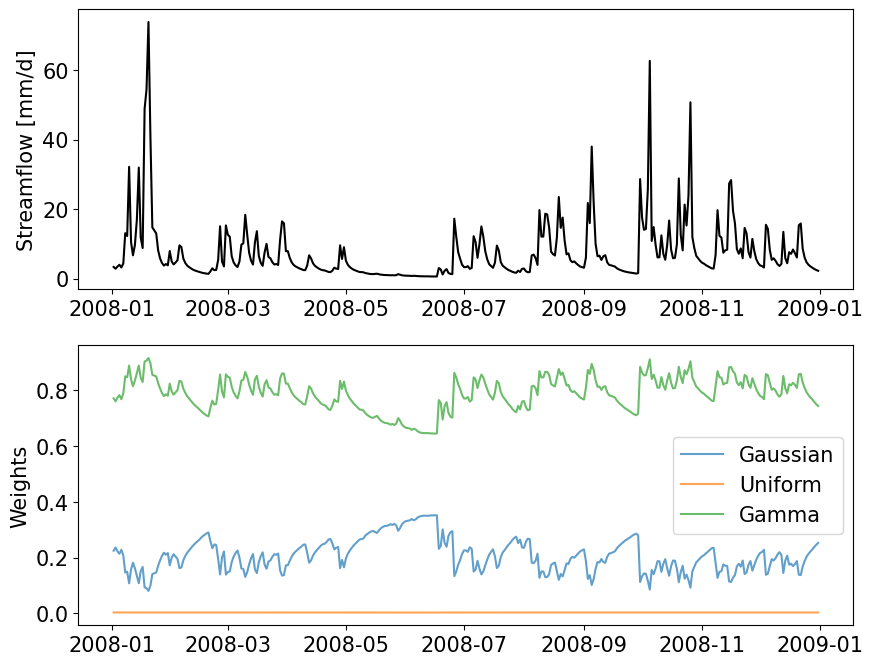

In [12]:
# MDN weights -- zoom in
distributions = ['Gaussian', 'Uniform', 'Gamma']
fig, axes = plt.subplots(2, 1, figsize=(10,8))
axes[0].plot(time[-365:], Q[-365:], 'k', label=dist)
# axes[0].plot(time[-365:], Q_pred[-365:], 'k--', label=dist)
for i,dist in enumerate(distributions):
    axes[1].plot(time[-365:], mdn_w[-365:,i], alpha=0.7, label=dist)
axes[0].set(ylabel='Streamflow [mm/d]')
axes[1].set(ylabel='Weights')
axes[1].legend()


array([<Axes: title={'center': 'Q age distribution ()'}, ylabel='Age [Days]'>,
       <Axes: title={'center': 'ET age distribution ()'}, ylabel='Age [Days]'>],
      dtype=object)

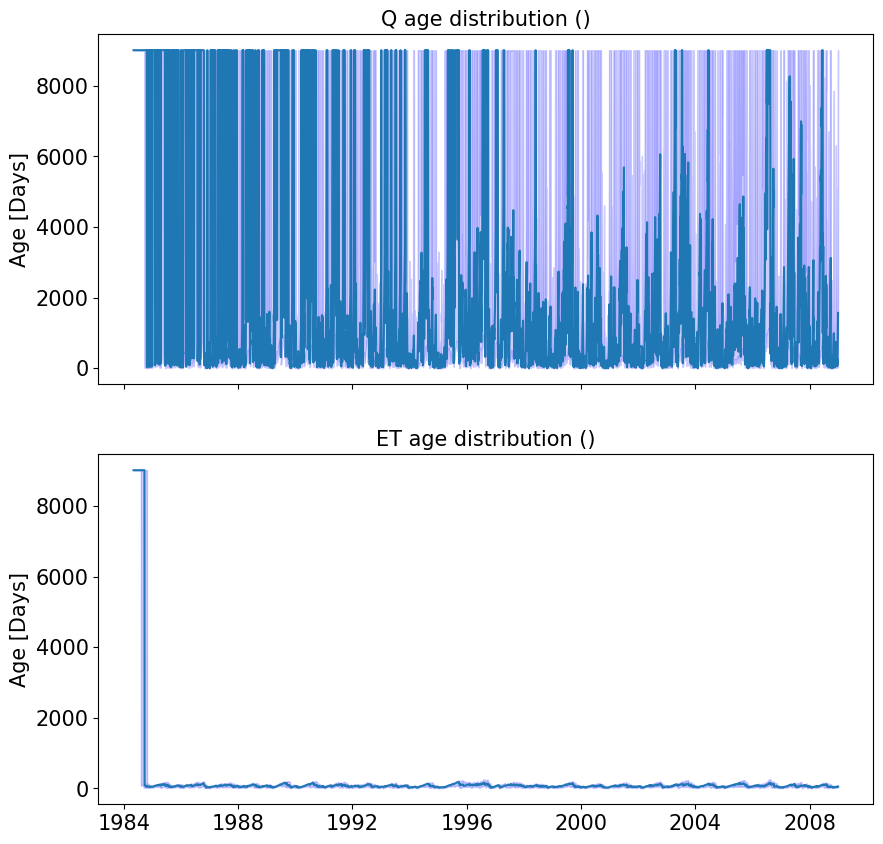

In [13]:
# Plot the age distribution
plot_PQET_quantile(pQETs, dt, time)


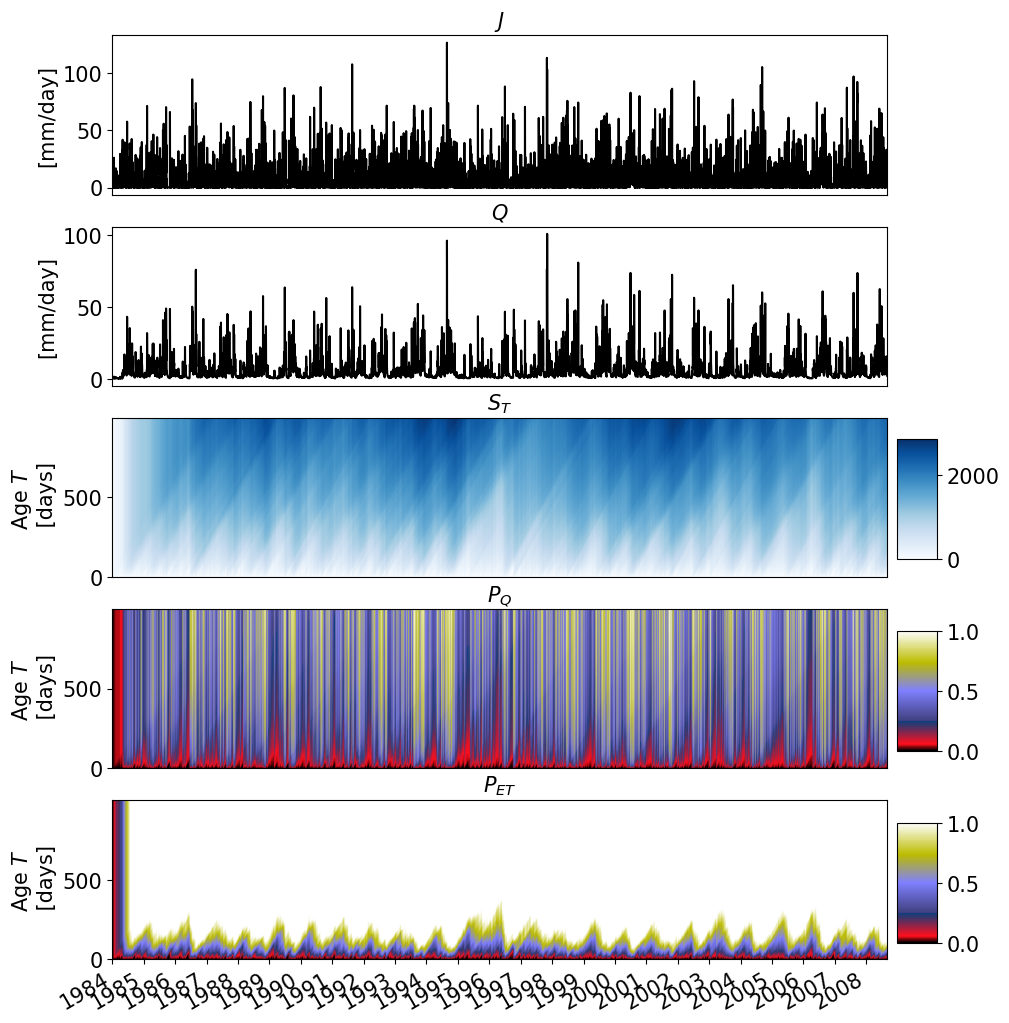

In [14]:
plot_PQET_ST(J, Q, sT, pQETs, dt, time, age_cut=1000);


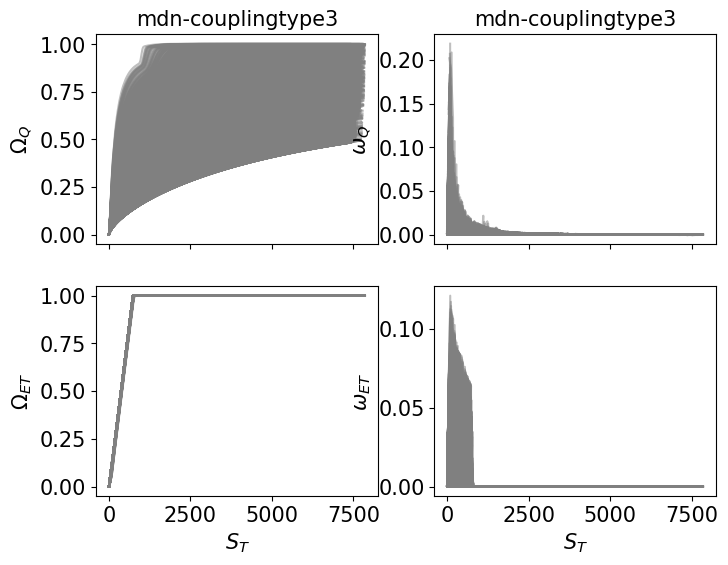

In [15]:
# Age distribution
axes = plot_PQET_ST2(sT, pQETs, dt, last_age_cut=2000, figsize=(8,6), label=model_name)


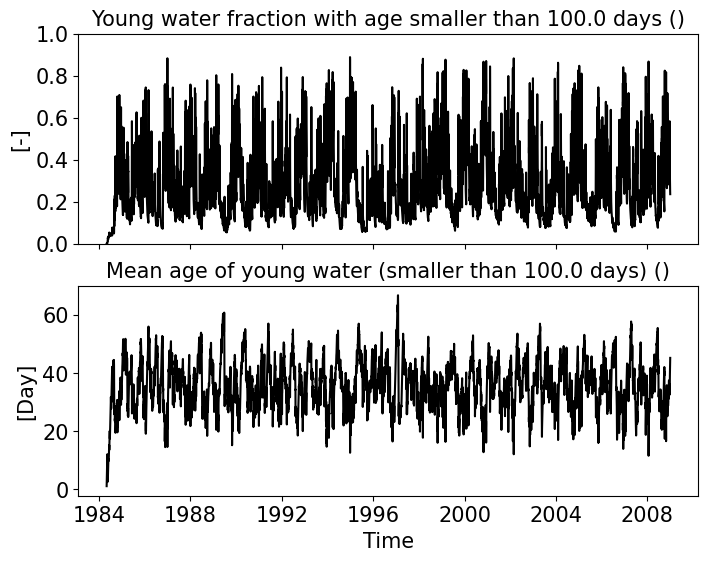

In [16]:
# Young water fraction in streamflow
plot_young_water(pQETs[...,0], time, dt=dt, cutoff_age=100);


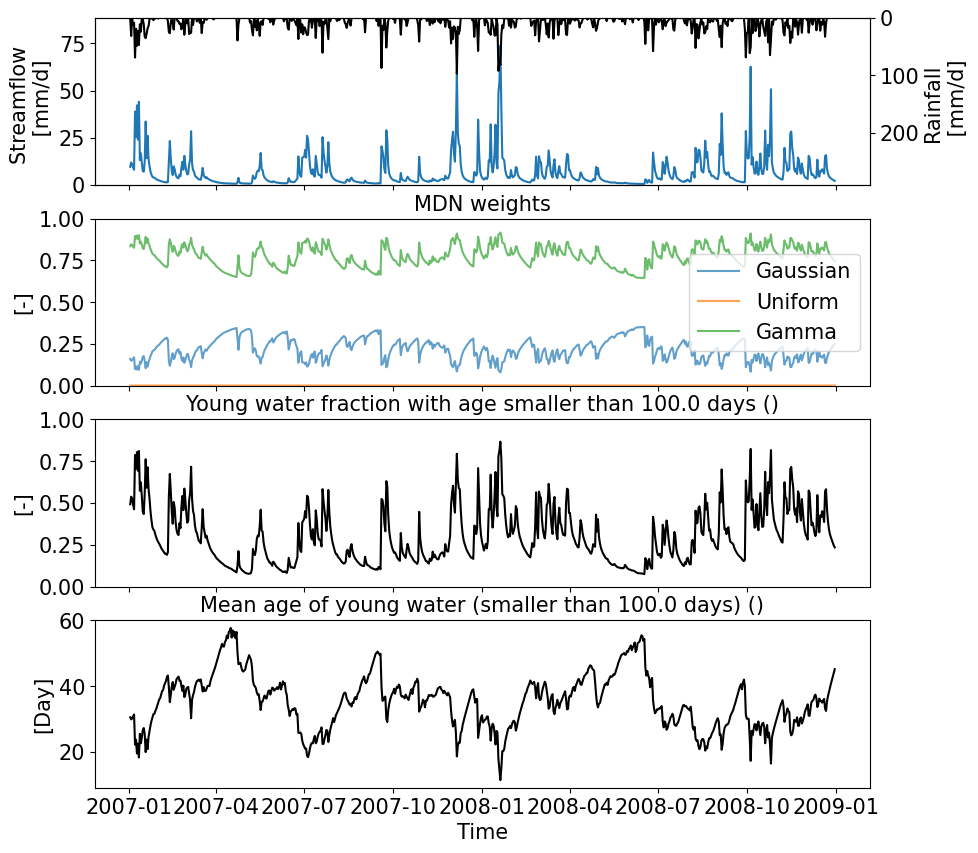

In [17]:
# MDN weights -- zoom in
cutoff=365*2
distributions = ['Gaussian', 'Uniform', 'Gamma']
fig, axes = plt.subplots(4, 1, figsize=(10,10), sharex=True)
plot_J_Q(J[-cutoff:], Q[-cutoff:], time[-cutoff:], ax=axes[0])
for i,dist in enumerate(distributions):
    axes[1].plot(time[-cutoff:], mdn_w[-cutoff:,i], alpha=0.7, label=dist)
axes[1].set(title='MDN weights', ylabel='[-]', ylim=[0,1])
axes[1].legend()
plot_young_water(pQETs[:,-cutoff:,0], time[-cutoff:], dt=dt, axes=axes[-2:], cutoff_age=100);
